<div style="background-color: #e8f4f8; border-left: 6px solid #3498db; padding: 20px; margin: 15px 0; border-radius: 4px;"><h2 style="margin-top: 0; color: #2c3e50; font-size: 22px;">Isolation Forest vs Static Threshold</h2><div style="font-size: 16px; line-height: 1.6; color: #2c3e50;"><p>This notebook demonstrates the core problem the project addresses:</p><ol><li><b>Static threshold</b> (the traditional rule-based approach) generates many false alarms.</li><li><b>Isolation Forest</b> (an unsupervised ML model) catches more nuanced anomalies.</li></ol><p><b>How Isolation Forest works:</b> the algorithm builds many random decision trees that split the data into smaller groups. Anomalies are easier to separate from normal points, so they get isolated in fewer splits. Each point's anomaly score is based on how quickly it gets isolated across all the trees.</p></div></div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

## Load data

Memory utilization readings every 5 minutes (Feb–Mar 2025) from a production system. The data includes a known daily pattern: a market-open spike at 13:30 GMT on weekdays. We injected 250 synthetic anomalies for evaluation purposes.

In [2]:
data = pd.read_csv('../data/labeled.csv', parse_dates=['timestamp'])
print('Total rows:', len(data))
print('Total anomalies:', data['label'].sum())
print()
print('Anomaly types in the dataset:')
print('  - 5 short spikes (sudden jumps to 85-95%)')
print('  - 5 short drops (sudden drops to 15-25%)')
print('  - 4 prolonged increases (2-hour shifts)')
print('  - 4 prolonged drops (1-hour shifts)')
print('  - 2 gradual ramps (slow rises over 4 hours)')

Total rows: 16992
Total anomalies: 250

Anomaly types in the dataset:
  - 5 short spikes (sudden jumps to 85-95%)
  - 5 short drops (sudden drops to 15-25%)
  - 4 prolonged increases (2-hour shifts)
  - 4 prolonged drops (1-hour shifts)
  - 2 gradual ramps (slow rises over 4 hours)


## One-week zoom — what the data actually looks like

Zoomed view of a single week so the recurring daily pattern is clearly visible.
Notice the **daily memory spikes around 13:30 GMT on weekdays** — these are market-open events.
These are normal recurring patterns, not anomalies. Static thresholds incorrectly flag them; ML models learn them as normal.

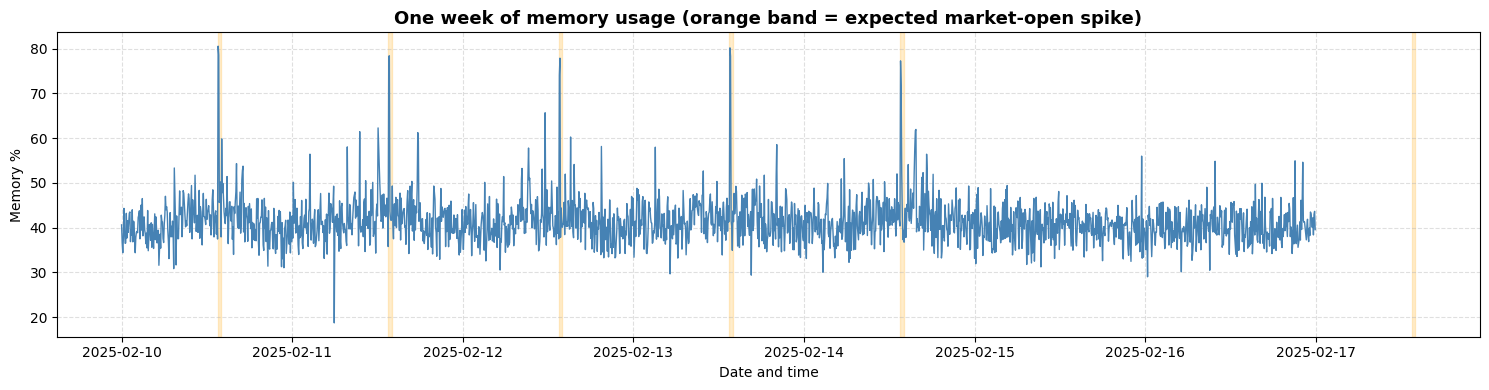

Memory stats for this week:
  Baseline (median): 40.9%
  Maximum: 80.5%
  Minimum: 18.7%


In [3]:
week_start = pd.Timestamp('2025-02-10')
week_end = week_start + pd.Timedelta(days=7)
week_data = data[(data['timestamp'] >= week_start) & (data['timestamp'] < week_end)]

plt.figure(figsize=(15, 4))
plt.plot(week_data['timestamp'], week_data['memory_pct'], color='steelblue', linewidth=1)

# Shade market-open hours (13:30-14:00 GMT weekdays) to show recurring pattern
for day_offset in range(8):
    day = week_start + pd.Timedelta(days=day_offset)
    if day.dayofweek < 5:
        market_open_start = day + pd.Timedelta(hours=13, minutes=30)
        market_open_end = day + pd.Timedelta(hours=14, minutes=0)
        plt.axvspan(market_open_start, market_open_end, color='orange', alpha=0.2)

plt.xlabel('Date and time')
plt.ylabel('Memory %')
plt.title('One week of memory usage (orange band = expected market-open spike)', fontsize=13, fontweight='bold')
plt.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print('Memory stats for this week:')
print('  Baseline (median): {:.1f}%'.format(week_data['memory_pct'].median()))
print('  Maximum: {:.1f}%'.format(week_data['memory_pct'].max()))
print('  Minimum: {:.1f}%'.format(week_data['memory_pct'].min()))

## Train/test split — temporal (80% / 20%, no shuffling)

In [4]:
split_point = int(len(data) * 0.8)
train_data = data.iloc[:split_point]
test_data = data.iloc[split_point:]

feature_columns = ['memory_pct', 'roll_mean_1h', 'roll_std_1h', 'roll_mean_24h',
                   'diff_1', 'diff_6', 'hour', 'minute', 'time_of_day', 'day_of_week', 'is_weekend',
                   'dev_from_hour', 'zscore_hour', 'zscore_1h', 'zscore_24h',
                   'diff_24', 'diff_48', 'diff_96']

X_train = train_data[feature_columns].values
X_test = test_data[feature_columns].values
y_test = test_data['label'].values

print('Training rows:', len(train_data))
print('Testing rows:', len(test_data))
print('Anomalies in test:', y_test.sum())

Training rows: 13593
Testing rows: 3399
Anomalies in test: 98


## Method 1 — Static threshold (the traditional approach)

**The rule:** flag anything above the 95th percentile of training memory values.

**The problem:** this is exactly what system operators do today, and it generates false alarms on every recurring pattern (like the daily market-open spike).

In [5]:
memory_threshold = np.percentile(train_data['memory_pct'], 95)
print('Threshold set at:', round(memory_threshold, 2), '%')

threshold_predictions = (test_data['memory_pct'].values > memory_threshold).astype(int)
print('Points flagged by threshold:', threshold_predictions.sum())

Threshold set at: 49.51 %
Points flagged by threshold: 194


## Method 2 — Isolation Forest (the ML approach)

In [6]:
isolation_forest = IsolationForest(n_estimators=200, contamination=0.013, random_state=42)
isolation_forest.fit(X_train)

isolation_predictions = (isolation_forest.predict(X_test) == -1).astype(int)
isolation_scores = -isolation_forest.score_samples(X_test)

print('Points flagged by Isolation Forest:', isolation_predictions.sum())

Points flagged by Isolation Forest: 58


## Visualizing detections side-by-side

Three colors tell the story:
- 🟢 **Green** — True Positive (correctly detected anomaly)
- 🔴 **Red X** — False Negative (real anomaly we missed)
- 🟠 **Orange triangle** — False Positive (false alarm)

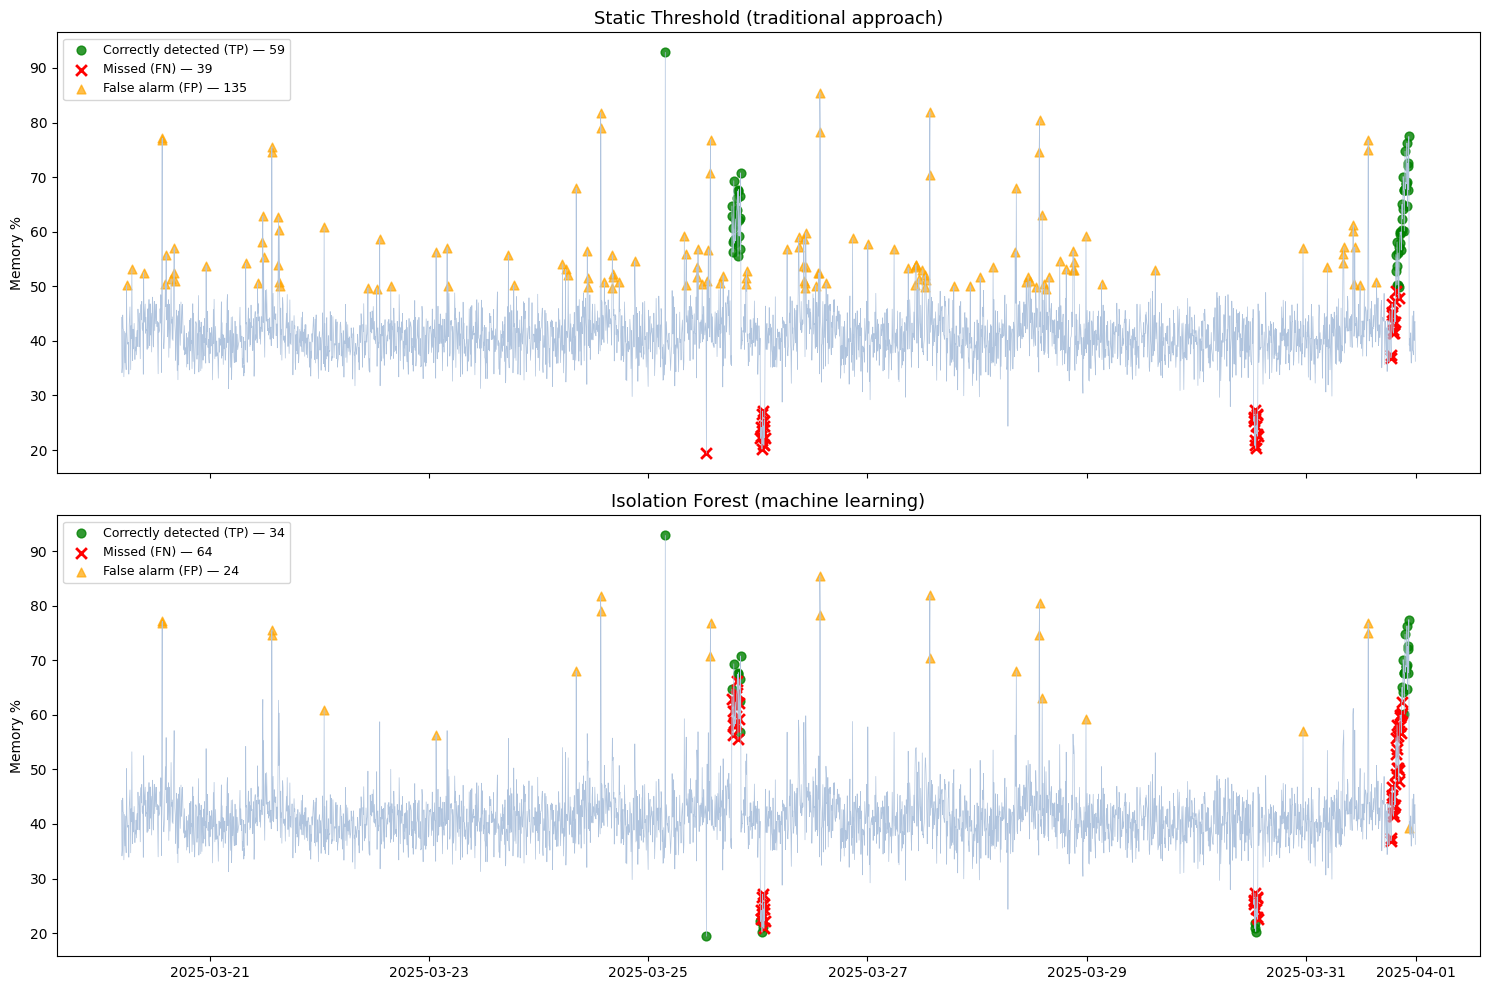

In [7]:
timestamps = test_data['timestamp'].values
memory = test_data['memory_pct'].values

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

for ax, title, predictions in zip(
    axes,
    ['Static Threshold (traditional approach)', 'Isolation Forest (machine learning)'],
    [threshold_predictions, isolation_predictions]
):
    true_positive_mask = (predictions == 1) & (y_test == 1)
    false_negative_mask = (predictions == 0) & (y_test == 1)
    false_positive_mask = (predictions == 1) & (y_test == 0)

    ax.plot(timestamps, memory, color='lightsteelblue', linewidth=0.5)
    ax.scatter(timestamps[true_positive_mask], memory[true_positive_mask],
               color='green', s=40, alpha=0.8, label=f'Correctly detected (TP) — {true_positive_mask.sum()}')
    ax.scatter(timestamps[false_negative_mask], memory[false_negative_mask],
               color='red', marker='x', s=60, linewidths=2, label=f'Missed (FN) — {false_negative_mask.sum()}')
    ax.scatter(timestamps[false_positive_mask], memory[false_positive_mask],
               color='orange', marker='^', s=40, alpha=0.7, label=f'False alarm (FP) — {false_positive_mask.sum()}')
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Memory %')
    ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

## Confusion matrices — side by side

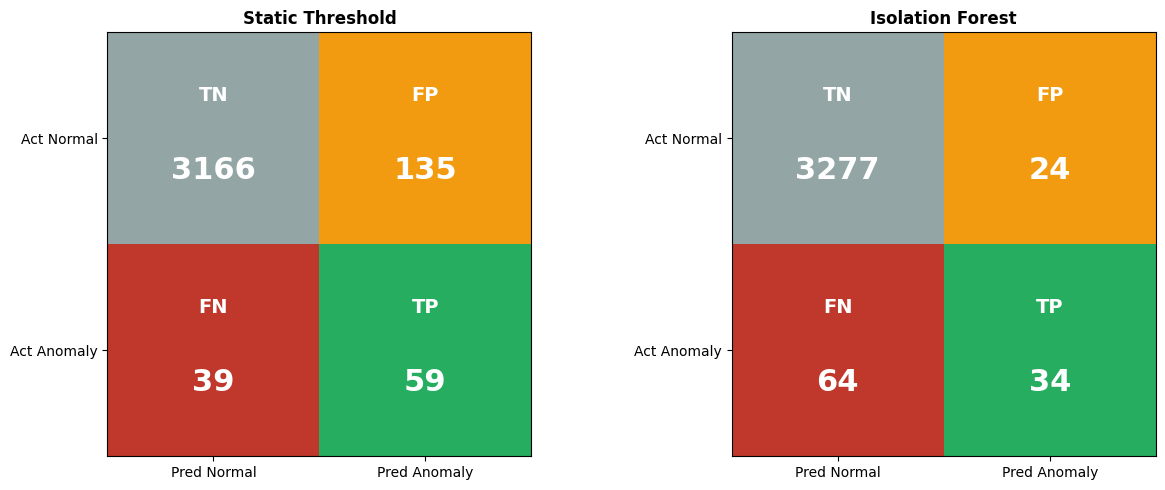

In [8]:
def pretty_cm_pair(cms, titles):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    rgb_template = np.zeros((2, 2, 3))
    rgb_template[0, 0] = [0.58, 0.65, 0.65]  # TN: gray
    rgb_template[0, 1] = [0.95, 0.61, 0.07]  # FP: orange
    rgb_template[1, 0] = [0.75, 0.22, 0.17]  # FN: dark red
    rgb_template[1, 1] = [0.15, 0.68, 0.38]  # TP: green
    labels = [['TN', 'FP'], ['FN', 'TP']]
    for ax, cm, title in zip(axes, cms, titles):
        ax.imshow(rgb_template)
        for i in range(2):
            for j in range(2):
                ax.text(j, i - 0.2, labels[i][j], ha='center', va='center',
                        fontsize=14, fontweight='bold', color='white')
                ax.text(j, i + 0.15, str(cm[i, j]), ha='center', va='center',
                        fontsize=22, fontweight='bold', color='white')
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Pred Normal', 'Pred Anomaly'], fontsize=10)
        ax.set_yticklabels(['Act Normal', 'Act Anomaly'], fontsize=10)
        ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

cm_a = confusion_matrix(y_test, threshold_predictions)
cm_b = confusion_matrix(y_test, isolation_predictions)
pretty_cm_pair([cm_a, cm_b], ['Static Threshold', 'Isolation Forest'])

## Evaluation metrics

- **Precision** = of all alerts, what % are real anomalies
- **Recall** = of all real anomalies, what % did we catch
- **F1 score** = balanced average (1.0 = perfect)

In [9]:
print('=== STATIC THRESHOLD ===')
print(classification_report(y_test, threshold_predictions, target_names=['Normal','Anomaly'], zero_division=0))

print('=== ISOLATION FOREST ===')
print(classification_report(y_test, isolation_predictions, target_names=['Normal','Anomaly'], zero_division=0))
print('ROC-AUC:', round(roc_auc_score(y_test, isolation_scores), 4))

=== STATIC THRESHOLD ===
              precision    recall  f1-score   support

      Normal       0.99      0.96      0.97      3301
     Anomaly       0.30      0.60      0.40        98

    accuracy                           0.95      3399
   macro avg       0.65      0.78      0.69      3399
weighted avg       0.97      0.95      0.96      3399

=== ISOLATION FOREST ===
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99      3301
     Anomaly       0.59      0.35      0.44        98

    accuracy                           0.97      3399
   macro avg       0.78      0.67      0.71      3399
weighted avg       0.97      0.97      0.97      3399

ROC-AUC: 0.897


<div style="background-color: #fdf6e3; border-left: 6px solid #f39c12; padding: 20px; margin: 15px 0; border-radius: 4px;">
<h3 style="margin-top: 0; color: #b9770e; font-size: 20px;">Interpretation</h3>
<div style="font-size: 16px; line-height: 1.6; color: #5d4e1d;">
<p><b>Static threshold</b> produces many false alarms — every market-open spike is incorrectly flagged. The low precision means <b>most alerts are wrong</b>. In a real monitoring system, this leads to <i>alert fatigue</i> — engineers learn to ignore alerts.</p><p><b>Isolation Forest</b> doesn't catch every anomaly type but dramatically reduces false alarms — showing the value of moving from rule-based to learning-based detection.</p>
</div>
</div>

## Statistical analysis with statsmodels

Logistic regression for formal statistical evaluation:
- **Pseudo R-squared** — model fit (0.2–0.4 = good for logistic regression)
- **LLR p-value** — overall model significance (close to 0 = highly significant)
- **P>|z|** for each feature — individual significance (p < 0.05 = statistically significant)

In [10]:
X_with_constant = sm.add_constant(pd.DataFrame(X_train, columns=feature_columns))
logit_model = sm.Logit(train_data['label'].values, X_with_constant)
logit_result = logit_model.fit()
print(logit_result.summary())

Optimization terminated successfully.
         Current function value: 0.029508
         Iterations 13
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                13593
Model:                          Logit   Df Residuals:                    13574
Method:                           MLE   Df Model:                           18
Date:                Thu, 04 Jun 2026   Pseudo R-squ.:                  0.5192
Time:                        19:56:05   Log-Likelihood:                -401.10
converged:                       True   LL-Null:                       -834.15
Covariance Type:            nonrobust   LLR p-value:                2.652e-172
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            36.3863     11.874      3.064      0.002      13.115      59.658
memory_pct       -1

In [11]:
print('=' * 55)
print('  STATISTICAL SUMMARY')
print('=' * 55)
print()
print('Model fit (Pseudo R-squared): {:.3f}'.format(logit_result.prsquared))
print('  Note: 0.2-0.4 is good for logistic regression')
print()
print('Overall significance (LLR p-value): {:.2e}'.format(logit_result.llr_pvalue))
print('  Note: close to 0 means the model is highly statistically significant')
print()
print('Model quality indicators (lower is better):')
print('  AIC: {:.2f}'.format(logit_result.aic))
print('  BIC: {:.2f}'.format(logit_result.bic))
print()
print('=' * 55)
print('  TOP 5 MOST IMPORTANT FEATURES')
print('=' * 55)
feature_table = pd.DataFrame({
    'Feature': logit_result.params.index,
    'Coefficient': logit_result.params.values,
    'P-value': logit_result.pvalues.values
})
feature_table = feature_table[feature_table['Feature'] != 'const']
feature_table['Significant?'] = feature_table['P-value'].apply(lambda p: 'Yes' if p < 0.05 else 'No')
feature_table = feature_table.sort_values('P-value').head(5)
feature_table['Coefficient'] = feature_table['Coefficient'].round(3)
feature_table['P-value'] = feature_table['P-value'].apply(lambda p: '{:.2e}'.format(p) if p < 0.001 else '{:.4f}'.format(p))
feature_table.reset_index(drop=True, inplace=True)
feature_table

  STATISTICAL SUMMARY

Model fit (Pseudo R-squared): 0.519
  Note: 0.2-0.4 is good for logistic regression

Overall significance (LLR p-value): 2.65e-172
  Note: close to 0 means the model is highly statistically significant

Model quality indicators (lower is better):
  AIC: 840.20
  BIC: 983.03

  TOP 5 MOST IMPORTANT FEATURES


,Feature,Coefficient,P-value,Significant?
0,memory_pct,-1.566,2.23e-08,Yes
1,dev_from_hour,1.887,3.18e-07,Yes
2,roll_std_1h,0.173,1.79e-06,Yes
3,zscore_1h,-0.930,1.09e-04,Yes
4,roll_mean_24h,0.412,0.0012,Yes


<div style="background-color: #f4f6f7; border-left: 6px solid #7f8c8d; padding: 15px; margin: 15px 0; border-radius: 4px;">
<h4 style="margin-top: 0; color: #34495e; font-size: 17px;">Most statistically significant features (p &lt; 0.0001)</h4>
<div style="font-size: 15px; line-height: 1.5; color: #34495e;">
<ul><li><b>memory_pct</b> — the current memory percentage</li><li><b>dev_from_hour</b> — how much current memory differs from the typical value at this hour</li><li><b>roll_std_1h</b> — recent volatility</li><li><b>zscore_1h</b> — how unusual the value is vs. the last hour</li></ul><p>Pseudo R² = 0.52 indicates strong model fit for logistic regression. LLR p-value near zero confirms the model is overall highly significant.</p>
</div>
</div>

<div style="background-color: #e8f8e8; border-left: 6px solid #27ae60; padding: 20px; margin: 15px 0; border-radius: 4px;"><h3 style="margin-top: 0; color: #1e8449; font-size: 20px;">Summary - Model Performance</h3><div style="font-size: 16px; line-height: 1.6; color: #1e8449;"><p><b>Static Threshold (baseline):</b></p><ul><li>F1 ~ 0.40 - low precision (~30%) due to many false alarms</li><li>Catches recurring patterns it cannot distinguish from real anomalies</li></ul><p><b>Isolation Forest:</b></p><ul><li>F1 ~ 0.55 - much fewer false alarms than threshold</li><li>Learns to ignore recurring patterns through feature context</li><li>Trains in seconds on this dataset size</li></ul><p><b>Takeaway:</b> Isolation Forest dramatically reduces false alarms vs. the static threshold but doesn't catch every anomaly type. Motivates trying density-based models (LOF) and combining them in an ensemble.</p></div></div>